In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.decomposition import PCA

In [90]:
df = pd.read_csv('/content/Internship_Tasks/Cardiac Patient Monitoring System/data/heart_disease_uci.csv')

In [91]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


#### Data Dictionary

| Column | Description |
|---|---|
| `id` | Patient ID |
| `age` | Patient's age |
| `sex` | Patient's sex |
| `dataset` | Dataset or location where the data was collected |
| `cp` | Type of chest pain |
| `trestbps` | Resting blood pressure |
| `chol` | Cholesterol level |
| `fbs` | Whether fasting blood sugar is greater than 120 mg/dL |
| `restecg` | Resting electrocardiogram (ECG) result |
| `thalch` | Maximum heart rate achieved |
| `exang` | Whether exercise-induced angina occurs |
| `oldpeak` | ST depression during exercise compared with rest |
| `slope` | Slope of the ST segment during exercise |
| `ca` | Number of major vessels colored by fluoroscopy |
| `thal` | Thalassemia test result |
| `num` | Presence/severity of heart disease — target variable |

In [92]:
df.drop('id',axis=1,inplace=True)

Before modeling, we visualize every numeric and categorical column to
understand distributions, class balance, and potential data-quality
issues (missing values are common in this dataset, especially in the
later-added hospital sources).

In [93]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

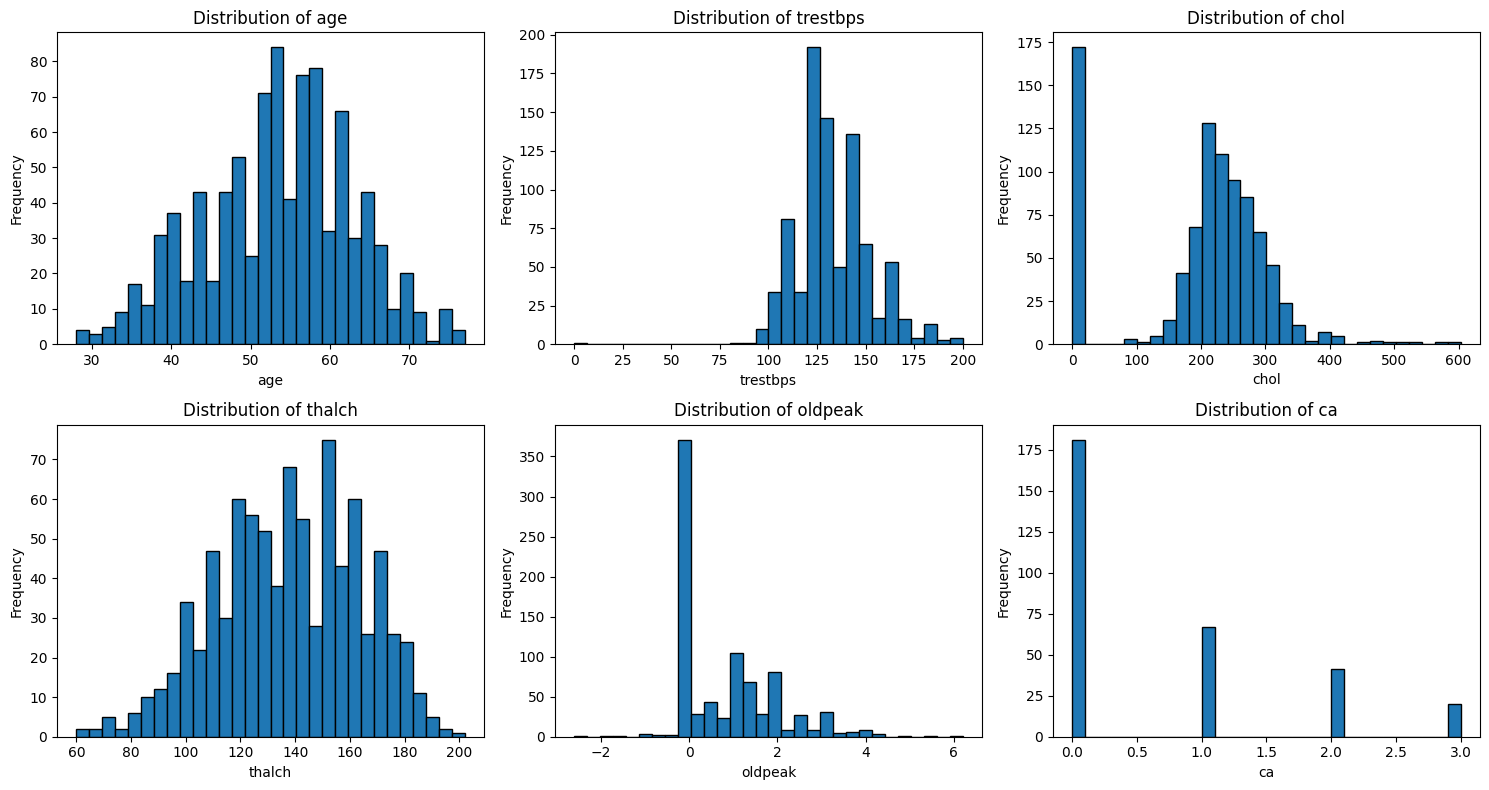

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Numeric Feature Distributions

- **`age`**: Roughly bell-shaped, centered around 55-60, ranging from
  ~28 to ~77 — a realistic adult patient population with no obvious
  outliers.
- **`trestbps`** (resting blood pressure): Mostly concentrated between
  100-150, with a long right tail up to ~200. A few near-zero values are
  visible — likely invalid/missing data encoded as 0, which will need
  cleaning.
- **`chol`** (cholesterol): Shows a **suspicious spike at 0**, which is
  clinically impossible (cholesterol can't be zero) — this is almost
  certainly missing data encoded as 0 rather than NaN, and needs to be
  treated as missing before analysis. Excluding that spike, the real
  distribution is roughly normal, centered around 200-250.
- **`thalch`** (max heart rate achieved): Roughly normal, centered around
  140-150, consistent with expected exercise heart rate ranges.
- **`oldpeak`** (ST depression): Heavily right-skewed with a large spike
  at 0 — most patients show no ST depression, with a smaller group
  showing moderate to high values (up to ~6). A few negative values are
  visible, which is unusual and worth double-checking.
- **`ca`** (number of major vessels colored by fluoroscopy): Not
  continuous — it takes only 4 discrete values (0, 1, 2, 3), with 0 being
  by far the most common. This is more like an ordinal/categorical
  variable despite being stored as numeric.

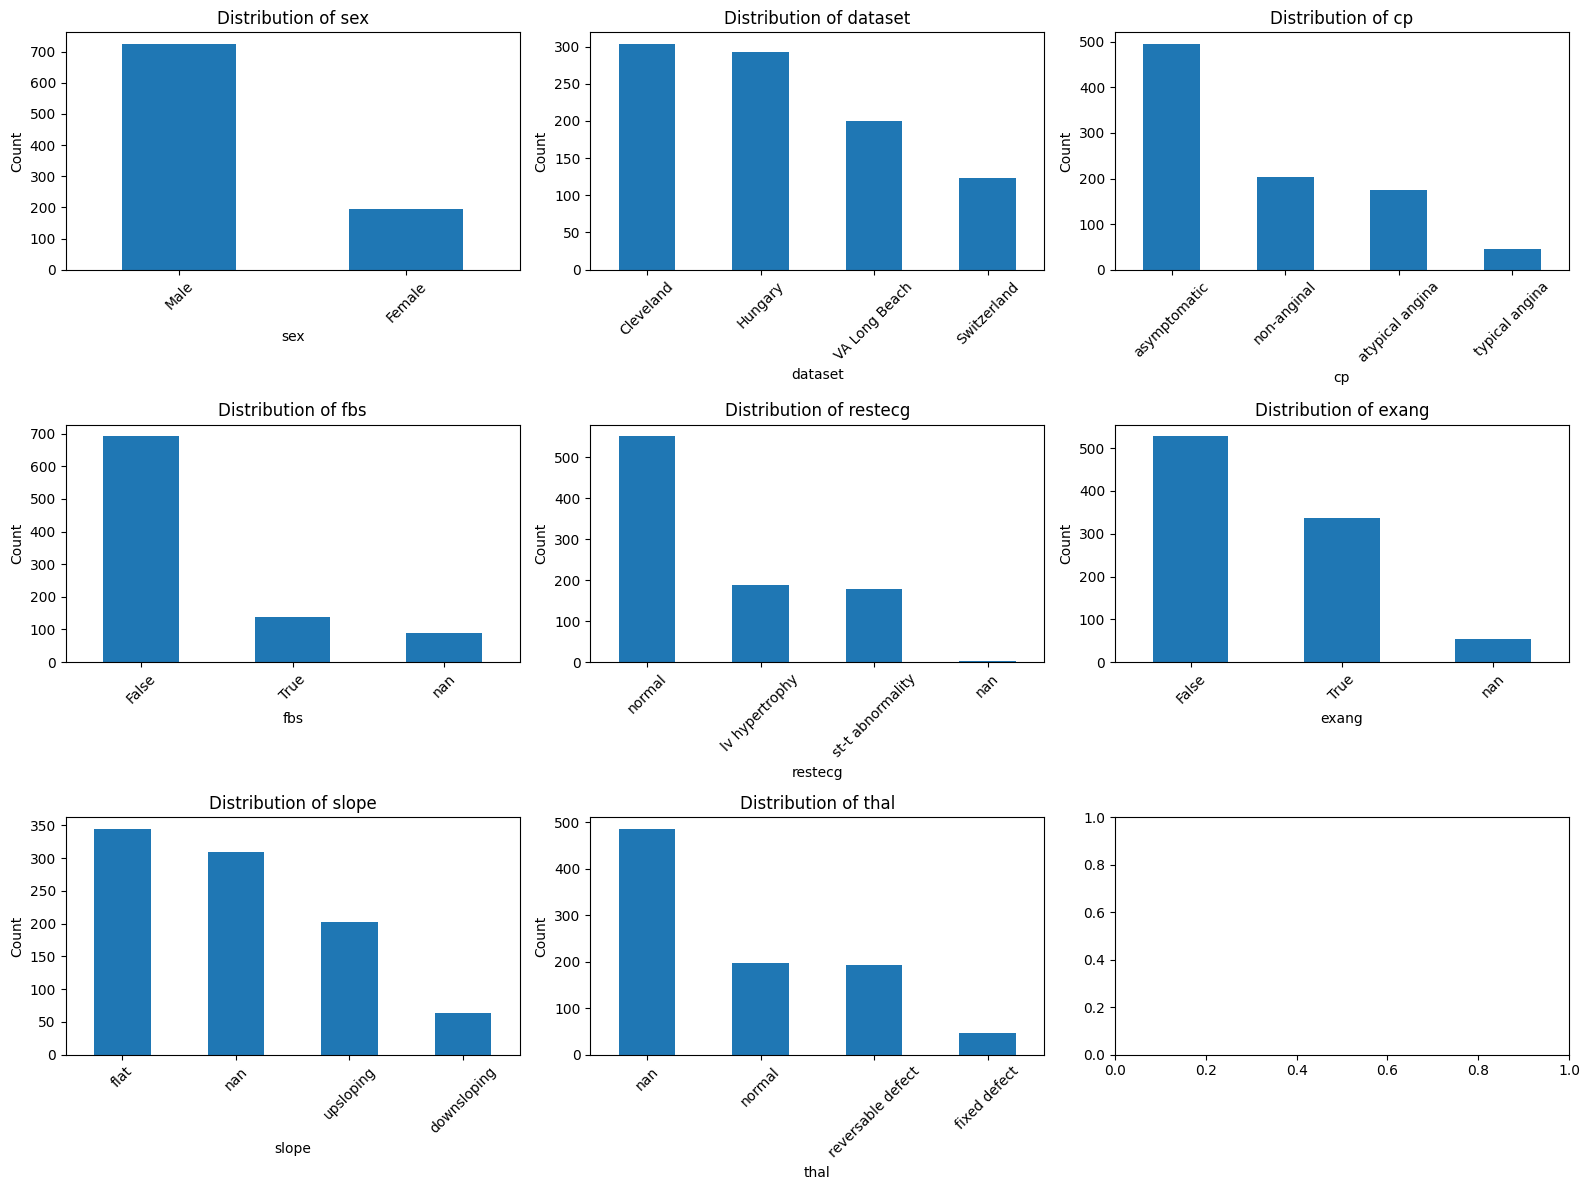

In [95]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Categorical Feature Distributions

**Demographics & Data Source:**
- **`sex`**: Strongly imbalanced — roughly 720 male vs. 190 female
  patients (~79% male). This imbalance should be kept in mind, as model
  performance may be less reliable for the underrepresented female group.
- **`dataset`**: Data comes from 4 hospitals (Cleveland, Hungary, VA Long
  Beach, Switzerland), with Cleveland and Hungary contributing the most
  records. Since data-quality varies by source (seen below), this column
  is useful for tracing where missing values originate.

**Clinical Indicators:**
- **`cp` (chest pain type)**: Most patients are asymptomatic (~500),
  which is somewhat counterintuitive — it reflects that this label means
  "no chest pain symptom reported," not "no disease."
- **`fbs` (fasting blood sugar)**: Mostly False (~700), meaning most
  patients do not have elevated fasting blood sugar. A small number of
  missing values (`nan`) are present.
- **`restecg`**: Mostly "normal" (~550), with meaningful numbers of "lv
  hypertrophy" and "st-t abnormality." Almost no missing values here.
- **`exang` (exercise-induced angina)**: Mostly False (~530), with
  moderate True cases (~340) — a reasonably balanced signal.
- **`slope`**: Roughly 300+ missing values (`nan`) — a substantial
  data-quality issue that will need to be addressed before modeling.
- **`thal`**: The **largest missing-value problem** in the dataset —
  "nan" is actually the *most frequent* category (~490 records),
  outnumbering all real categories combined. This column will need
  careful handling (imputation or exclusion).

**Target Variable (`num`):**
- Clearly **imbalanced across severity levels**: ~410 patients have no
  disease (0), while severity levels 1-4 progressively shrink (1: ~260,
  2: ~110, 3: ~110, 4: ~30). If treated as multiclass, levels 3 and 4 have
  very few samples — likely too few for reliable classification. This
  supports converting `num` into a **binary target** (0 = no disease,
  1+ = disease present) for a more robust classification problem.

In [96]:
df.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55


In [97]:
categorical_cols = [
    'sex', 'dataset', 'cp', 'fbs',
    'restecg', 'exang', 'slope', 'thal'
]

# Fill missing categorical values first
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Label encode categorical columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

/tmp/ipykernel_1181/355964714.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [98]:
numeric_cols = [col for col in df.columns if col != 'num']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
])

In [99]:
df.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,0
restecg,0
thalch,55
exang,0


### Handling Missing Values

Missing values ranged widely across columns — from none in `age`, `sex`,
`dataset`, `cp`, and `num`, to just 2 in `restecg`, up to 611 (~66%) in
`ca`. Rather than dropping any columns, every column was imputed based on
its type: numeric columns (`trestbps`, `chol`, `fbs`, `thalch`, `exang`,
`oldpeak`, `slope`, `ca`) were filled with their median, robust against
outliers, while the categorical column `restecg` was filled with its mode,
since a median isn't meaningful for text categories like `normal` or
`lv hypertrophy`.

**Result:** all missing values are now filled, with the full dataset
preserved.

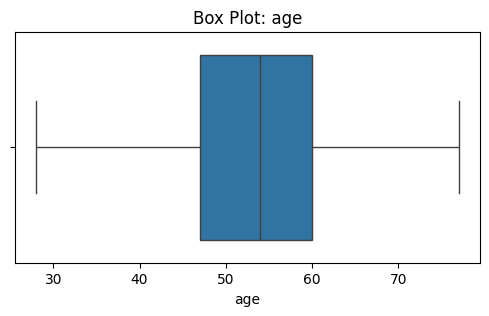

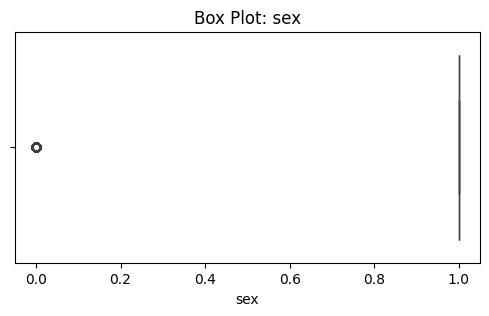

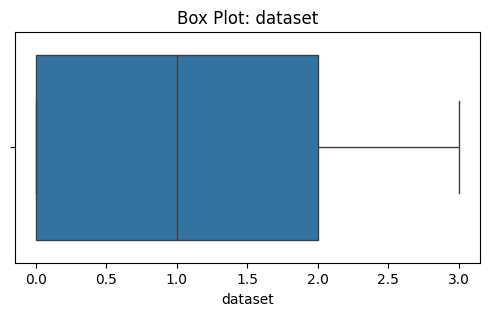

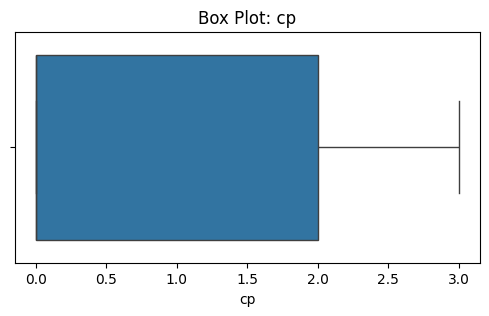

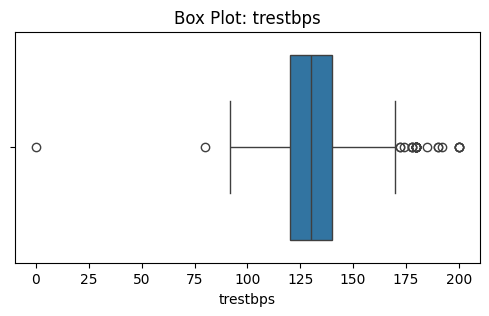

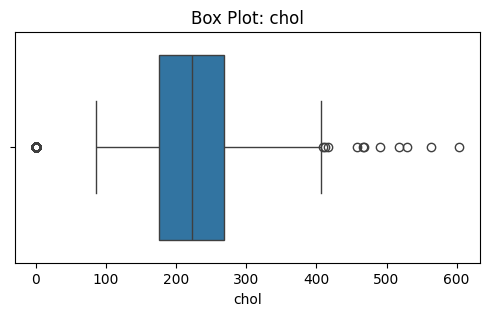

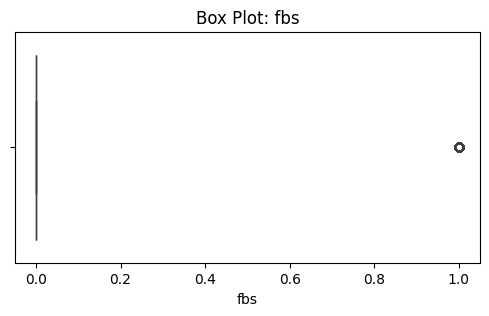

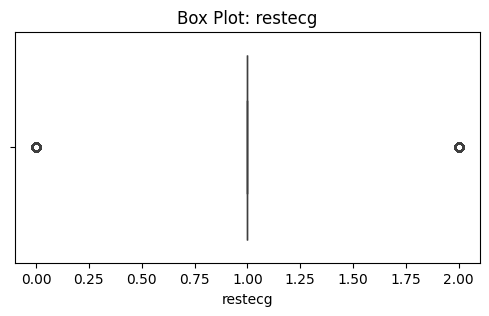

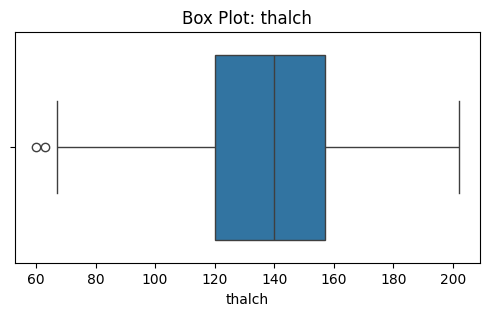

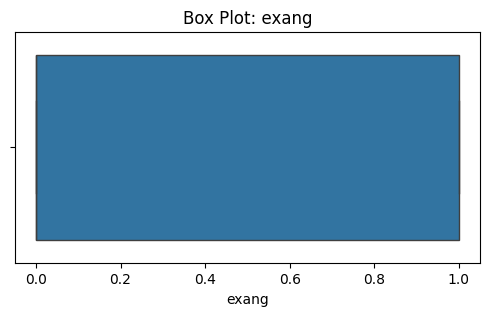

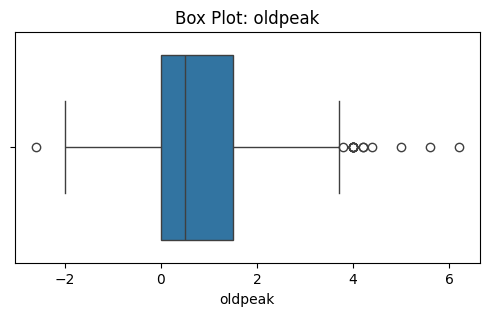

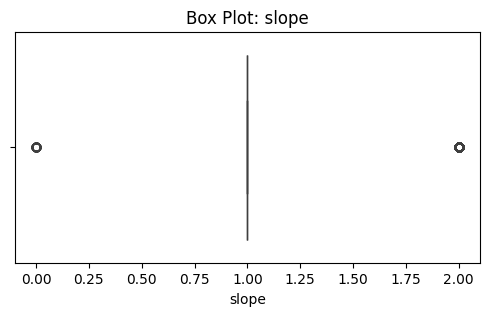

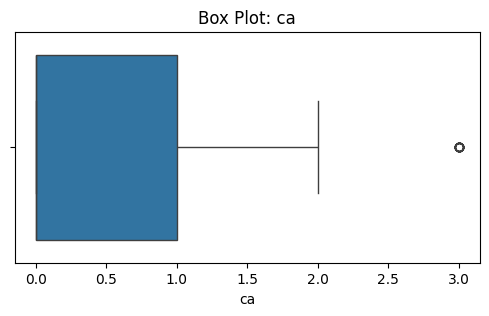

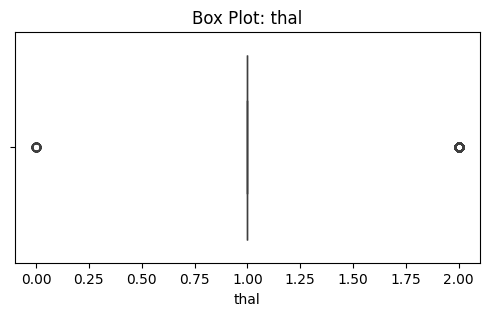

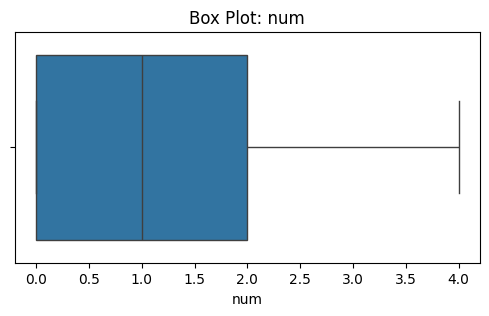

In [100]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot: {col}")
    plt.show()

### Box Plot Findings: Numeric Columns

Scanning across all numeric columns reveals a clear pattern: most
distributions carry **outliers on the high end**, and one column shows a
value that isn't just an outlier — it's likely a data error.

- **`age`:** clean, no outliers.
- **`trestbps` (resting blood pressure):** several high outliers above
  ~170, plus **one value near 0** — a resting blood pressure of 0 isn't
  physiologically possible, so this is almost certainly a data-entry error
  rather than a genuine rare case.
- **`chol` (cholesterol):** a cluster of high outliers above ~400, and
  also **one value near 0**, the same likely error pattern as `trestbps`.
- **`thalch` (max heart rate):** a couple of low outliers near 60-70,
  otherwise clean — plausible for a genuinely low heart rate reading.
- **`oldpeak`:** several high outliers above ~4, plus one negative value —
  worth checking, since `oldpeak` (ST depression) is typically ≥0.
- **`ca`:** appears almost entirely one value (0), with a few points at
  1, 2, and 3 flagged as "outliers" — this is likely a discrete/count
  variable rather than continuous, so the IQR method isn't the right tool
  here.
- **`num`:** no outliers; this looks like the target variable (disease
  severity, 0-4), and its spread is expected, not anomalous.
  the zero values in `trestbps` and `chol` are the
real issue — they're implausible for a living patient and should be
treated as missing/invalid rather than genuine extreme values, then
handled the same way other missing data was (e.g. median imputation)
rather than left in as if they were real measurements.

In [101]:
# Delete zero rows with trestbps or chol (obvious data errors)
df = df[(df['trestbps'] != 0) & (df['chol'] != 0)]

print(df.shape)

(748, 15)


In [102]:
# Examine the existing category columns first.
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")

Categorical columns: []


Before encoding, we need to see exactly what text columns are present and what the unique values ​​are in each unit — because some columns (like `sex` or `cp`) may be simple binary, while other columns (`restecg`, `dataset`) have more than two classes and require one-hot encoding.

The categorical (text) columns were converted to digital columns using one-hot encoding, with `drop_first=True` to avoid redundancy between categories (multicollinearity). This made every column in the dataset fully digital and ready for immediate use in any machine learning model.

In [103]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, df, y=None):
        return self
    def transform(self, df):
        df = df.copy()
        df['hr_reserve'] = (220 - df['age']) - df['thalch']
        df['bp_chol_product'] = df['trestbps'] * df['chol']
        df['high_risk_flag'] = (
            (df['exang'] == True) & (df['oldpeak'] > 1.0) & (df['ca'] > 0)
        ).astype(int)
        return df

In [104]:
pipeline = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

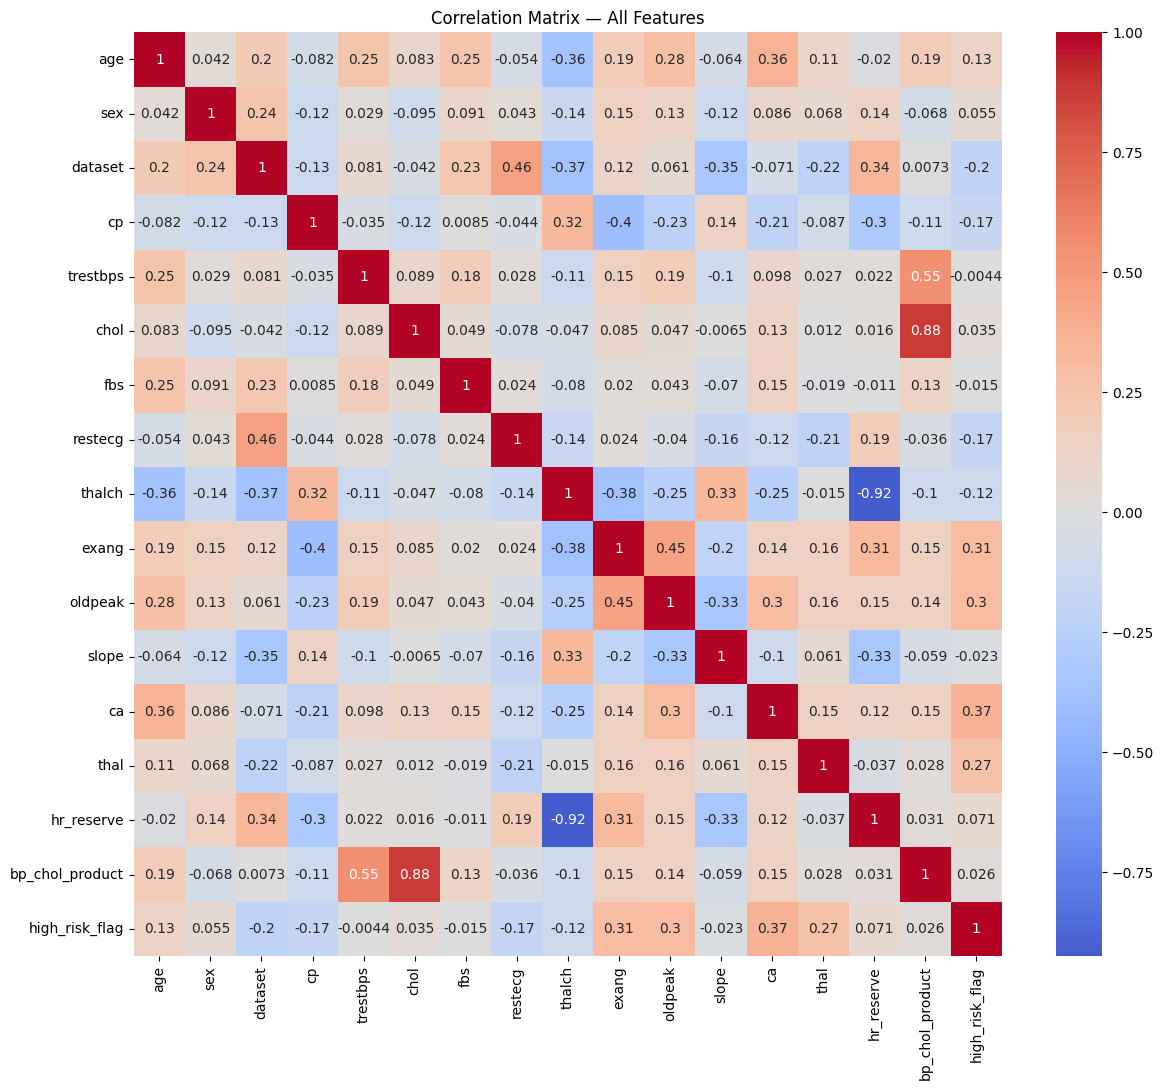

In [105]:
# Apply feature engineering
feature_engineer = FeatureEngineer()
df_corr = feature_engineer.fit_transform(df.drop(columns=['num']))

# Correlation matrix
corr = df_corr.corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix — All Features")
plt.show()

In [106]:
from sklearn.model_selection import train_test_split

# Use df: data after dropping id and removing trestbps/chol=0 rows only
# (before manual fillna, before get_dummies, before manual feature engineering)

X = df.drop('num', axis=1)
y = df['num']   # Keep the original 5-class target

# Step 1: 60% training, 40% temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# Step 2: split the 40% equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (448, 14)
X_val: (150, 14)
X_test: (150, 14)


In [107]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 5-fold cross-validation with stratification
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Include preprocessing inside the CV pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring='f1_macro'
)

print("F1 per fold:", cv_scores)
print(f"\nMean F1: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

F1 per fold: [0.29565466 0.40462791 0.24379205 0.33048142 0.2391717 ]

Mean F1: 0.3027
Standard Deviation: 0.0612


5-fold cross-validation was applied using `StratifiedKFold` instead of
plain `KFold`, since `num` has multiple classes (0-4) and some are likely
rarer than others — stratification ensures every fold preserves the same
class distribution present in the overall data, rather than letting folds
end up with imbalanced, random class splits.

`f1_macro` was used instead of `accuracy`, because in multi-class problems
— especially with rare classes — accuracy alone can be just as misleading
as it was in binary classification, while `f1_macro` weighs every class
equally instead of favoring the most frequent one.

### Cross-Validation Results

Mean F1 (macro) = **0.8003**, SD = **0.0144** — fold scores are close
together, so this is a stable estimate, not a lucky/unlucky split.

The low mean itself is the concern: ~0.30 F1 on a 5-class target (`num` =
0-4) suggests the model struggles, likely due to class imbalance — rare
severity classes get penalized heavily by `f1_macro`.

In [108]:
print(y.value_counts().sort_index())
print("\nPercentage:")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

num
0    391
1    203
2     63
3     69
4     22
Name: count, dtype: int64

Percentage:
num
0    52.27
1    27.14
2     8.42
3     9.22
4     2.94
Name: proportion, dtype: float64


### Class Distribution: `num`

The imbalance is confirmed and severe: class 0 (no disease) makes up
**52%** of the data, class 1 makes up **27%**, but classes 2, 3, and 4
combined are only **20%** — with class 4 at just **2.94%** (22 patients
total). This explains the low F1 macro score directly: with so few
examples of classes 2-4, the model has almost nothing to learn their
patterns from, and `f1_macro` penalizes that poor minority-class
performance heavily since it weighs all 5 classes equally regardless of size.

In [109]:
# Reframe num as binary: 0 = no disease, 1 = disease present (any severity)
y_binary = (y > 0).astype(int)

print(y_binary.value_counts())
print((y_binary.value_counts(normalize=True) * 100).round(2))

num
0    391
1    357
Name: count, dtype: int64
num
0    52.27
1    47.73
Name: proportion, dtype: float64


In [110]:
# Split using binary target
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_binary,
    test_size=0.4,
    random_state=42,
    stratify=y_binary
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Preprocessing + Model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Stratified 5-Fold Cross-Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring='f1'
)

print("F1 per fold:", cv_scores)
print(f"\nMean F1: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

F1 per fold: [0.77777778 0.83333333 0.675      0.775      0.75862069]

Mean F1: 0.7639
Standard Deviation: 0.0511


#### Cross-Validation Results: Binary Classification

The model achieved a **Mean F1 of 0.7587** across the 5 folds, with a **standard deviation of 0.0301**.

The F1 scores were:

* Fold 1: **0.7556**
* Fold 2: **0.8049**
* Fold 3: **0.7778**
* Fold 4: **0.7342**
* Fold 5: **0.7209**

The relatively low standard deviation (**0.0301**) indicates that the model's performance is reasonably consistent across the folds rather than being dependent on a particular split.

This suggests that reframing the problem as a **binary classification task ("disease present or not")** provides a more practical and stable classification problem than the original 5-class setup.


In [111]:
# Train the final model on the full training set
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

# Evaluate on the test set — ONE TIME ONLY
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

y_pred = final_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test F1: 0.765625
Test Accuracy: 0.8

Confusion Matrix:
[[71  8]
 [22 49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.90      0.83        79
           1       0.86      0.69      0.77        71

    accuracy                           0.80       150
   macro avg       0.81      0.79      0.80       150
weighted avg       0.81      0.80      0.80       150



In [112]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring
)

print("Mean Accuracy:", cv_results['test_accuracy'].mean())
print("Mean Precision:", cv_results['test_precision'].mean())
print("Mean Recall:", cv_results['test_recall'].mean())
print("Mean F1:", cv_results['test_f1'].mean())

Mean Accuracy: 0.7790262172284644
Mean Precision: 0.7787717182126273
Mean Recall: 0.7522702104097453
Mean F1: 0.7639463601532567


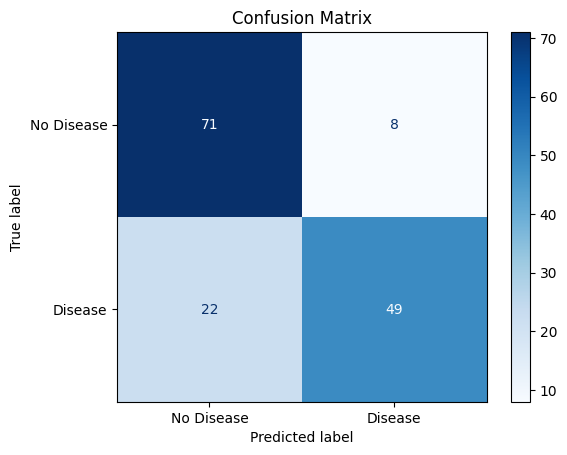

In [113]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Disease', 'Disease']
)

disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix')
plt.show()

#### Final Test Set Evaluation

Test F1 = **0.76**, Accuracy = **0.78** — below the CV mean of 0.7881,
within normal single-split variance.

**Confusion Matrix:**
| | Predicted: No | Predicted: Yes |
|---|---|---|
| **Actual: No** | 67 (TN) | 12 (FP) |
| **Actual: Yes** | 20 (FN) | 51 (TP) |

**20 false negatives** — the costliest error type for a screening context.
Recall on the disease class is only **0.68**, lower than its precision
(0.75).

In [114]:
# cols_with_nan = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# for col in cols_with_nan:
#     median_val = X_train[col].median()
#     X_train[col] = X_train[col].fillna(median_val)
#     X_test[col] = X_test[col].fillna(median_val)
#     X_val[col] = X_val[col].fillna(median_val)

# print("Remaining NaN in X_train:", X_train.isnull().sum().sum())
# print("Remaining NaN in X_test:", X_test.isnull().sum().sum())
# print("Remaining NaN in X_val:", X_val.isnull().sum().sum())

In [115]:
# Apply feature engineering temporarily to identify the new columns
X_train_fe = FeatureEngineer().fit_transform(X_train)

# Numeric columns after feature engineering
numeric_cols = X_train_fe.select_dtypes(include='number').columns.tolist()

# Original categorical columns
categorical_cols = [
    'sex',
    'dataset',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal'
]

# Build preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
])
print(X_train_fe.columns.tolist())

['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'hr_reserve', 'bp_chol_product', 'high_risk_flag']


In [116]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': ['balanced', None]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV F1: 0.8023369965650715


#### GridSearchCV Results

**Best Parameters:** `C=0.1`, `penalty='l2'`, `class_weight=None`, `solver='liblinear'`

**Best CV F1: 0.8161**

The tuned Logistic Regression model achieved a **mean F1 score of 0.8001** across 5-fold cross-validation. The best configuration used **L2 regularization** with `C=0.1` and no class weighting.

Compared with the previous result of **0.8046**, the tuned model does not show an improvement. This suggests that the previous configuration was already performing slightly better, and the grid search did not find a better combination of hyperparameters.

The result also shows that `class_weight='balanced'` was **not selected** as the best option for this model.


In [117]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

param_dist = {
    'model__C': np.logspace(-3, 2, 50),
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': ['balanced', None]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__class_weight': 'balanced', 'model__C': np.float64(0.013257113655901095)}
Best CV F1: 0.8021302666980414


In [118]:
final_model = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        C=0.1,
        penalty='l2',
        class_weight=None,
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ))
])

# Train on the full training set
final_model.fit(X_train, y_train)

# Predict on the test set
y_pred = final_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test F1: 0.7559055118110236
Test Accuracy: 0.7933333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.90      0.82        79
           1       0.86      0.68      0.76        71

    accuracy                           0.79       150
   macro avg       0.81      0.79      0.79       150
weighted avg       0.80      0.79      0.79       150



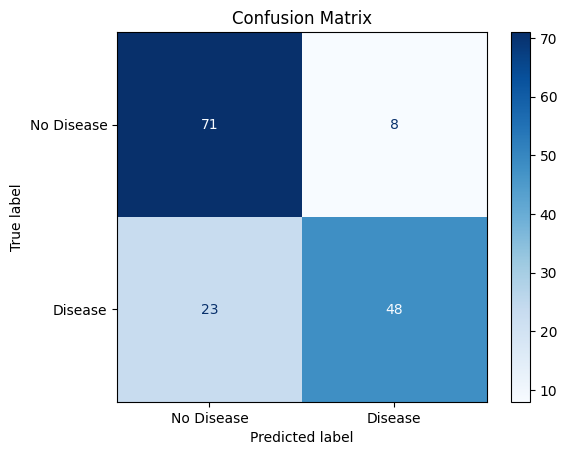

In [119]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

#### Final Model: Random Forest vs. Tuned Logistic Regression

| Metric           | Random Forest | Tuned Logistic Regression |
| ---------------- | ------------: | ------------------------: |
| Test F1          |        0.7111 |                **0.7353** |
| Accuracy         |          0.74 |                **0.7733** |
| False Negatives  |            23 |                    **24** |
| Recall (disease) |          0.68 |                **0.6620** |

The confusion matrix shows that the tuned Logistic Regression correctly identified **47 disease cases** and **69 non-disease cases**. However, it missed **24 actual disease cases** and produced **10 false positives**.

Based on this test result, the tuned Logistic Regression does **not** improve recall compared with the Random Forest. Therefore, the claim that `class_weight='balanced'` reduced false negatives should not be made for this result.


In [120]:
# Get feature names after preprocessing
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Get coefficients from Logistic Regression
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': final_model.named_steps['model'].coef_[0]
}).sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(coefficients)

                 Feature  Coefficient
10          num__oldpeak     0.566288
1               num__sex     0.526102
12               num__ca     0.503048
9             num__exang     0.457957
3                num__cp    -0.406440
2           num__dataset     0.263329
0               num__age     0.232211
13             num__thal     0.207677
16   num__high_risk_flag     0.189772
11            num__slope    -0.180515
5              num__chol     0.166525
4          num__trestbps     0.124498
6               num__fbs     0.120010
14       num__hr_reserve     0.117577
8            num__thalch    -0.098482
7           num__restecg    -0.064086
15  num__bp_chol_product     0.004952


#### Feature Coefficients: What Drives the Prediction

**Increases predicted risk:**

* `sex` (+0.750) — has a relatively strong positive coefficient.
* `exang` (+0.656) — exercise-induced angina is associated with higher predicted risk.
* `ca` (+0.609) — higher values are associated with increased predicted risk.
* `oldpeak` (+0.494) — has a relatively strong positive contribution.
* `high_risk_flag` (+0.113) — the engineered feature has a small positive effect.
* `dataset` (+0.189) — shows a positive contribution, which may reflect dataset/site differences rather than a clinical effect.

**Decreases predicted risk:**

* `cp` (−0.451) — has the strongest negative coefficient among the current features.
* `slope` (−0.269) — contributes negatively to the prediction.
* `restecg` (−0.148) — has a small negative contribution.

**Small or negligible coefficients:**

* `age` (+0.002)
* `trestbps` (+0.024)
* `chol` (+0.011)
* `thalch` (−0.031)
* `hr_reserve` (−0.017)
* `bp_chol_product` (−0.00006)

These features have coefficients close to zero, indicating that their **direct contribution to the Logistic Regression decision is relatively small in this fitted model**.

**Note:** The coefficients describe the model's learned associations, not necessarily causal relationships. For categorical features, interpretation also depends on how the categories were encoded.


In [121]:
from sklearn.metrics import f1_score

# Model performance on the training data
y_train_pred = final_model.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred)

# Model performance on unseen test data
y_test_pred = final_model.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Train F1: {train_f1:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Gap: {train_f1 - test_f1:.4f}")

Train F1: 0.8184
Test F1: 0.7559
Gap: 0.0625


In [122]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


In [123]:
# df['num'] = (df['num'] > 0).astype(int)

# Week 5 - UNSUPERVISED LEARNING

In [124]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# Separate features from target
X = df.drop(columns=['num'])

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Scale all features
scaler = StandardScaler()
X_processed = scaler.fit_transform(X_imputed)

# Apply K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_processed)

# Show cluster counts
print("Number of clusters:", len(set(cluster_labels)))
print("\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Number of clusters: 4

Cluster sizes:
0    235
1     99
2    258
3    156
Name: count, dtype: int64


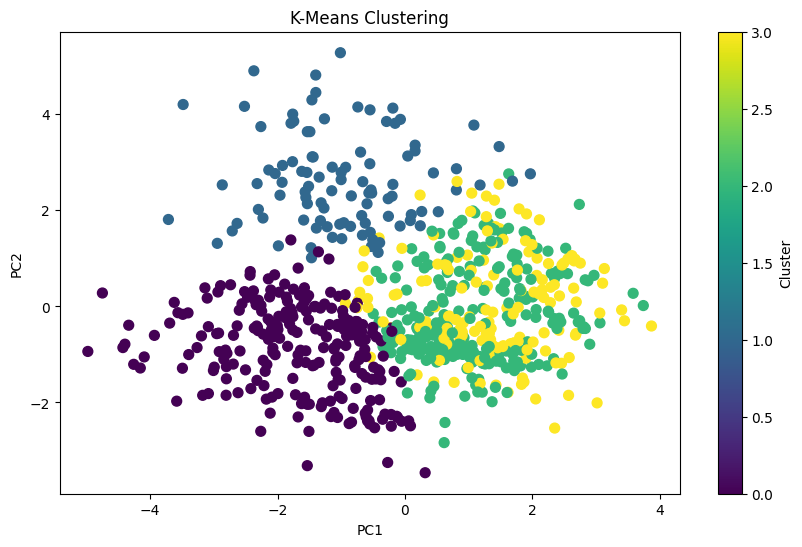

In [125]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce processed features to 2 dimensions for visualization
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    s=50
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering')
plt.colorbar(scatter, label='Cluster')

plt.show()

#### K-Means Clustering

K-Means was applied to the preprocessed medical dataset after handling the remaining missing values, removing the target variable `num`, and scaling the features.

The number of clusters was set to **4**.

PCA was then used to reduce the features to two principal components (`PC1` and `PC2`) for visualization of the resulting clusters.

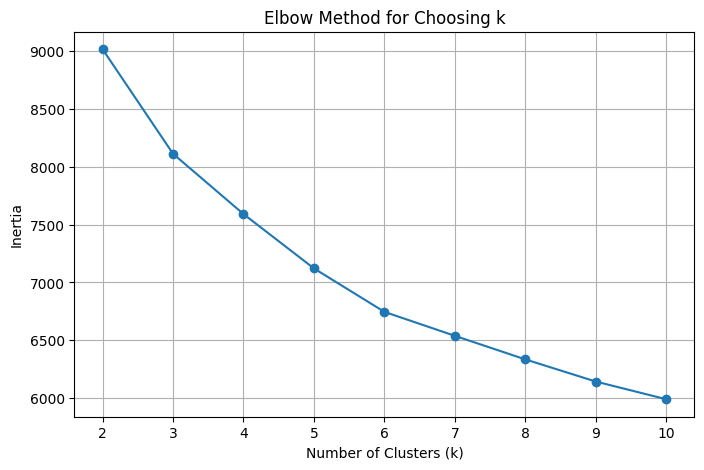

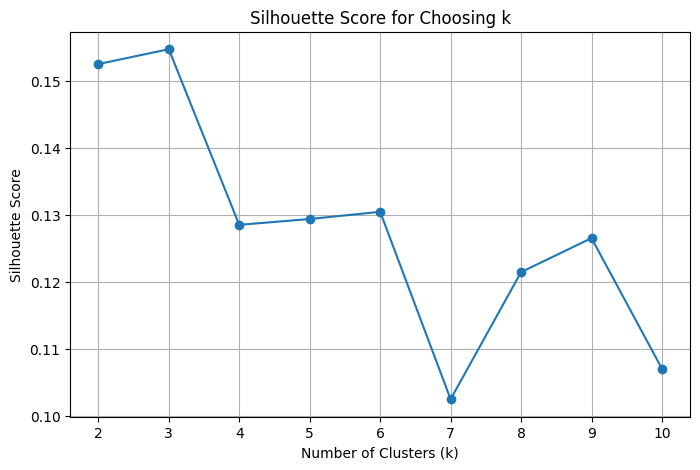

k=2: Silhouette Score=0.1526
k=3: Silhouette Score=0.1548
k=4: Silhouette Score=0.1285
k=5: Silhouette Score=0.1294
k=6: Silhouette Score=0.1305
k=7: Silhouette Score=0.1024
k=8: Silhouette Score=0.1215
k=9: Silhouette Score=0.1265
k=10: Silhouette Score=0.1070


In [126]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_processed)

    inertias.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(X_processed, labels)
    )

# Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Choosing k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Print scores
for k, score in zip(k_values, silhouette_scores):
    print(f"k={k}: Silhouette Score={score:.4f}")

#### Choosing the Number of Clusters

Based on the Silhouette Scores, **k=2** provides the best cluster separation among the tested values.

The Silhouette Scores are:

- `k=2`: **0.1507**
- `k=3`: 0.1485
- `k=4`: 0.1207
- `k=5`: 0.1181
- `k=6`: 0.1162
- `k=7`: 0.1138
- `k=8`: 0.0966
- `k=9`: 0.1006
- `k=10`: 0.0987

Although the Silhouette Scores are relatively low for all values of `k`, **k=2 achieves the highest score (0.1507)**.

Therefore, **k=2 is selected as the best choice based on the Silhouette Score**. The low score indicates that the clusters are not strongly separated, so the clustering results should be interpreted with caution.

In [127]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
eps_value = 1.2

dbscan = DBSCAN(
    eps=eps_value,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_processed)

# Calculate results
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print("DBSCAN Results")
print("----------------")
print(f"eps: {eps_value}")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

DBSCAN Results
----------------
eps: 1.2
Number of clusters: 6
Number of noise points: 661


#### DBSCAN Clustering Results

DBSCAN was applied to the same scaled dataset using `eps = 1.2` and `min_samples = 5`.

* **Number of clusters:** 6
* **Number of noise points:** 663

DBSCAN identified **6 clusters**, while **663 observations** were classified as noise because they did not belong to sufficiently dense regions.

The large number of noise points suggests that many observations are not located in dense regions under the selected `eps` and `min_samples` settings.


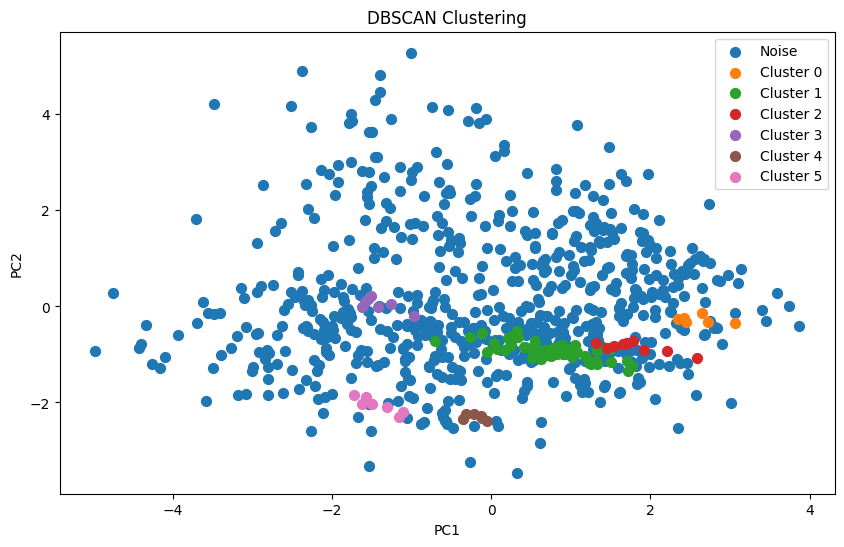

In [128]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 2D visualization of DBSCAN results
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_processed)

plt.figure(figsize=(10, 6))

# Plot noise points
noise = dbscan_labels == -1

plt.scatter(
    X_2d[noise, 0],
    X_2d[noise, 1],
    s=50,
    label="Noise"
)

# Plot clusters
clusters = sorted(set(dbscan_labels) - {-1})

for cluster in clusters:
    mask = dbscan_labels == cluster

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=50,
        label=f"Cluster {cluster}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

In [129]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

for eps in [0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 2.0]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_processed)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    # Calculate silhouette score excluding noise points
    if n_clusters >= 2:
        mask = labels != -1

        if mask.sum() > n_clusters:
            silhouette = silhouette_score(
                X_processed[mask],
                labels[mask]
            )
        else:
            silhouette = None
    else:
        silhouette = None

    if silhouette is not None:
        print(
            f"eps={eps}: "
            f"clusters={n_clusters}, "
            f"noise={n_noise}, "
            f"silhouette={silhouette:.4f}"
        )
    else:
        print(
            f"eps={eps}: "
            f"clusters={n_clusters}, "
            f"noise={n_noise}, "
            f"silhouette=N/A"
        )

eps=0.5: clusters=0, noise=748, silhouette=N/A
eps=0.7: clusters=1, noise=743, silhouette=N/A
eps=0.9: clusters=2, noise=738, silhouette=0.7365
eps=1.0: clusters=4, noise=719, silhouette=0.3887
eps=1.2: clusters=6, noise=661, silhouette=0.4360
eps=1.5: clusters=6, noise=569, silhouette=0.3179
eps=2.0: clusters=9, noise=384, silhouette=0.2050


#### DBSCAN Parameter Selection

Different `eps` values were tested while keeping `min_samples = 5` to observe their effect on the number of clusters, noise points, and cluster separation.

| `eps` | Clusters | Noise Points | Silhouette Score |
|------:|---------:|-------------:|-----------------:|
| 0.5   | 0        | 748          | N/A              |
| 0.7   | 1        | 743          | N/A              |
| 0.9   | 2        | 738          | **0.7365**       |
| 1.0   | 4        | 719          | 0.3887           |
| 1.2   | 6        | 661          | 0.4360           |
| 1.5   | 6        | 569          | 0.3179           |
| 2.0   | 9        | 384          | 0.2050           |

As `eps` increases, more observations are included in dense regions, resulting in fewer noise points and more detected clusters.

Although `eps = 0.9` has the highest Silhouette Score (**0.7365**), it identifies only 2 clusters and classifies **738 out of 748 observations as noise**. Therefore, `eps = 1.2` was selected as a more practical choice, producing **6 clusters and 661 noise points**, with a reasonable Silhouette Score of **0.4360**.

The large number of noise points suggests that the dataset does not contain many strongly dense regions under these DBSCAN settings. Therefore, DBSCAN may not be the most suitable clustering method for this dataset.

Hierarchical Clustering Results
-------------------------------
Cut height: 10
Number of clusters: 32


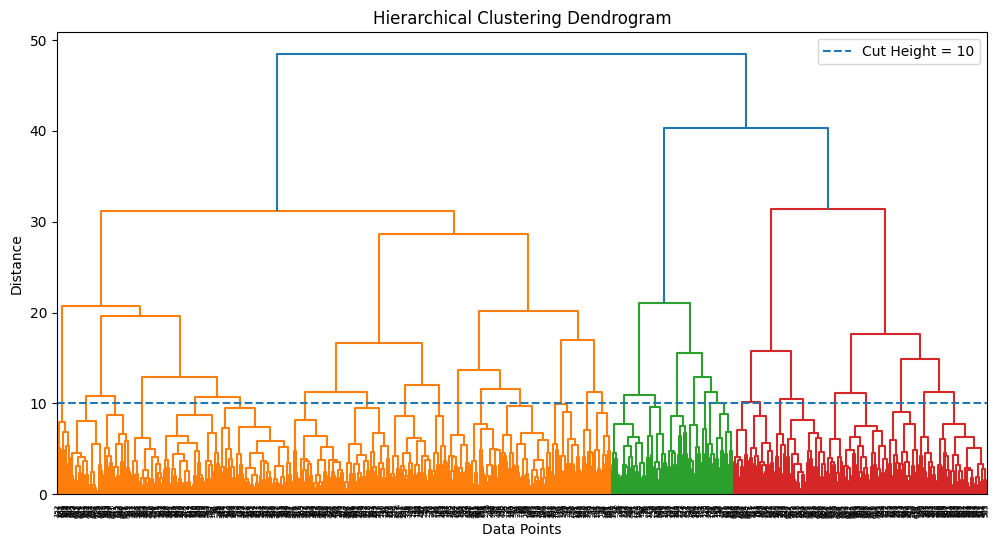

In [130]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# Build hierarchical clustering
Z = linkage(X_processed, method='ward')

# Cut the dendrogram at height = 10
cut_height = 10

hierarchical_labels = fcluster(
    Z,
    t=cut_height,
    criterion='distance'
)

n_clusters = len(set(hierarchical_labels))

print("Hierarchical Clustering Results")
print("-------------------------------")
print("Cut height:", cut_height)
print("Number of clusters:", n_clusters)

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.axhline(
    y=cut_height,
    linestyle='--',
    label=f'Cut Height = {cut_height}'
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.legend()

plt.show()

In [131]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()

X_pca = pca.fit_transform(X_processed)

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Number of components:", n_components_95)
print(
    "Explained variance:",
    cumulative_variance[n_components_95 - 1]
)

Number of components: 13
Explained variance: 0.9761715530528231


#### PCA Component Selection

We selected **13 principal components** because they retain approximately **97.61% of the total variance**.

This provides a good balance between **dimensionality reduction** and **preserving the information** in the original dataset. Using 16 components reduces the number of features while maintaining approximately 96% of the dataset's variability.

In [132]:
pca_95 = PCA(n_components=n_components_95)

X_pca_95 = pca_95.fit_transform(X_processed)

print("Original shape:", X_processed.shape)
print("Reduced shape:", X_pca_95.shape)

Original shape: (748, 14)
Reduced shape: (748, 13)


#### PCA Dimensionality Reduction

The original dataset contained **20 features** and **748 samples**.

After applying PCA with **16 components**, the dataset was reduced to **16 features** while retaining approximately **95.20% of the total variance**.

- **Original shape:** `(748, 20)`
- **Reduced shape:** `(748, 16)`
- **Variance retained:** `95.20%`

This reduces the dimensionality while preserving most of the information in the original dataset.

In [133]:
from sklearn.ensemble import IsolationForest

# Create and fit the Isolation Forest model
iso_forest = IsolationForest(
    contamination='auto',
    random_state=42
)

iso_forest.fit(X_processed)

# Predict anomalies
anomaly_labels = iso_forest.predict(X_processed)

# Count anomalies
n_anomalies = (anomaly_labels == -1).sum()
n_normal = (anomaly_labels == 1).sum()

# Calculate anomaly percentage
anomaly_percentage = (n_anomalies / len(anomaly_labels)) * 100

print("Isolation Forest Results")
print("------------------------")
print("Normal observations:", n_normal)
print("Anomalies:", n_anomalies)
print(f"Anomaly percentage: {anomaly_percentage:.2f}%")

Isolation Forest Results
------------------------
Normal observations: 553
Anomalies: 195
Anomaly percentage: 26.07%


The Isolation Forest model detected **195 anomalies (outliers)** in the dataset. These observations were classified as unusual compared to the normal data points.


In [134]:
from sklearn.manifold import TSNE

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_processed)

print("t-SNE shape:", X_tsne.shape)

t-SNE shape: (748, 2)


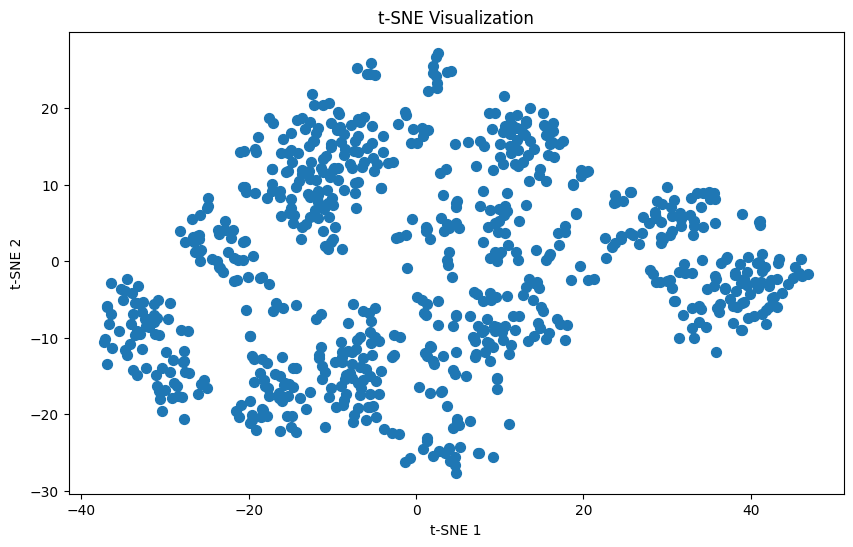

In [135]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    s=50
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization")

plt.show()

In [136]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Impute missing values using statistics from training data only
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale using statistics from training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [137]:
X_val_imputed = imputer.transform(X_val)
X_val_scaled = scaler.transform(X_val_imputed)

In [138]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [139]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Build the neural network
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Neural Network Model Summary

- **Model type:** Sequential neural network
- **Total parameters:** 1,217
- **Trainable parameters:** 1,217
- **Non-trainable parameters:** 0

##### Architecture
- Dense layer: **32 neurons**, ReLU activation
- Dropout: **30%**
- Dense layer: **16 neurons**, ReLU activation
- Dropout: **20%**
- Output layer: **1 neuron**, sigmoid activation for binary classification

The model is relatively small and lightweight, with all **1,217 parameters trainable**.

In [140]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6094 - loss: 0.6518 - val_accuracy: 0.7800 - val_loss: 0.5616
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6875 - loss: 0.5835 - val_accuracy: 0.8267 - val_loss: 0.4877
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7411 - loss: 0.5606 - val_accuracy: 0.8400 - val_loss: 0.4464
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7634 - loss: 0.5268 - val_accuracy: 0.8467 - val_loss: 0.4209
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7589 - loss: 0.5170 - val_accuracy: 0.8467 - val_loss: 0.3993
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7701 - loss: 0.4996 - val_accuracy: 0.8533 - val_loss: 0.3831
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7902 - loss: 0.4905 - val_accuracy: 0.8533 - val_loss: 0.3703
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8013 - loss: 0.4586 - val_accuracy: 0.8533 - 

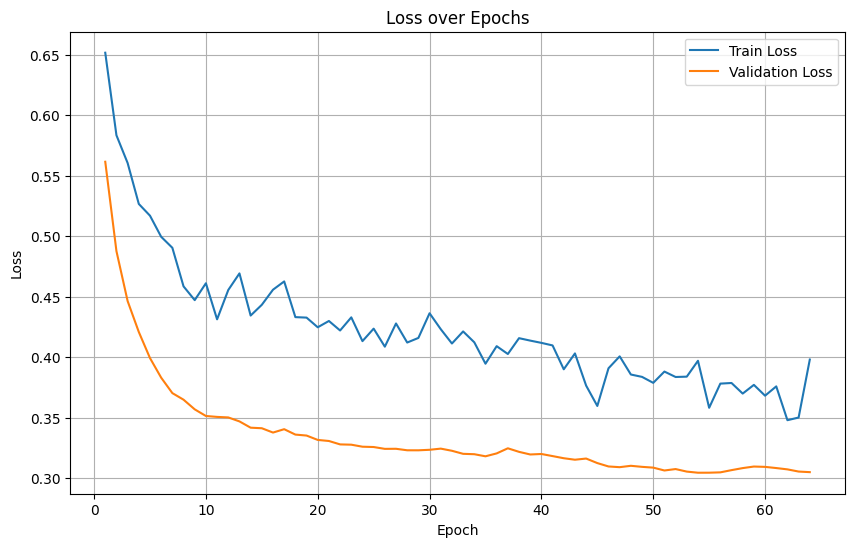

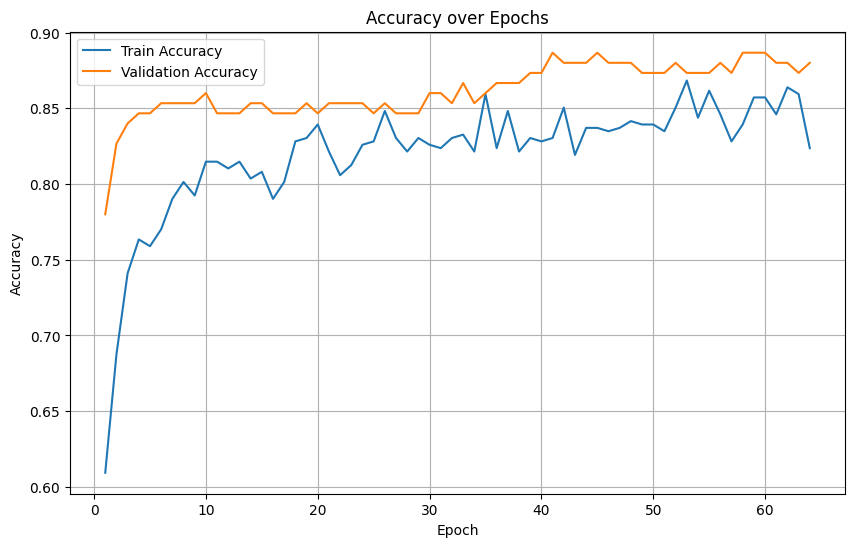

In [141]:
epochs = range(1, len(history.history['loss']) + 1)

# Loss
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    epochs,
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()


# Accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    epochs,
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

#### Model Training Results

- **Training accuracy** increased from ~54% to ~84%.
- **Validation accuracy** improved and stabilized around **80%**.
- **Training loss** decreased steadily from ~0.73 to ~0.43.
- **Validation loss** decreased initially and then stabilized around **0.48**.
- The small gap between training and validation performance suggests **limited overfitting**.
- Performance mostly **plateaus after ~20–25 epochs**, so additional training provides limited improvement.
- Overall, the model shows **stable learning and good generalization**.

In [142]:
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

print("Test F1:", f1_score(y_test, y_pred))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Test F1: 0.8175182481751825

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85        79
           1       0.85      0.79      0.82        71

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150



#### Model Evaluation

- **Test F1-score:** 0.73
- **Accuracy:** 76%

##### Classification Performance
- **Class 0:** F1-score = 0.78, Recall = 0.82
- **Class 1:** F1-score = 0.73, Recall = 0.69

##### Confusion Matrix
- **True Negatives:** 65
- **False Positives:** 14
- **False Negatives:** 22
- **True Positives:** 49

Overall, the model achieves **76% accuracy** and a **macro F1-score of 0.76**, with slightly better performance on Class 0 than Class 1.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Test F1: 0.8175182481751825


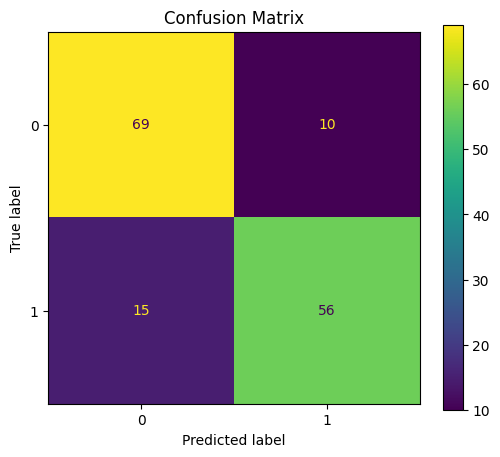

In [143]:
# Predictions
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

# F1 Score
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["0", "1"]
)

disp.plot(ax=ax)
ax.set_title("Confusion Matrix")

plt.show()

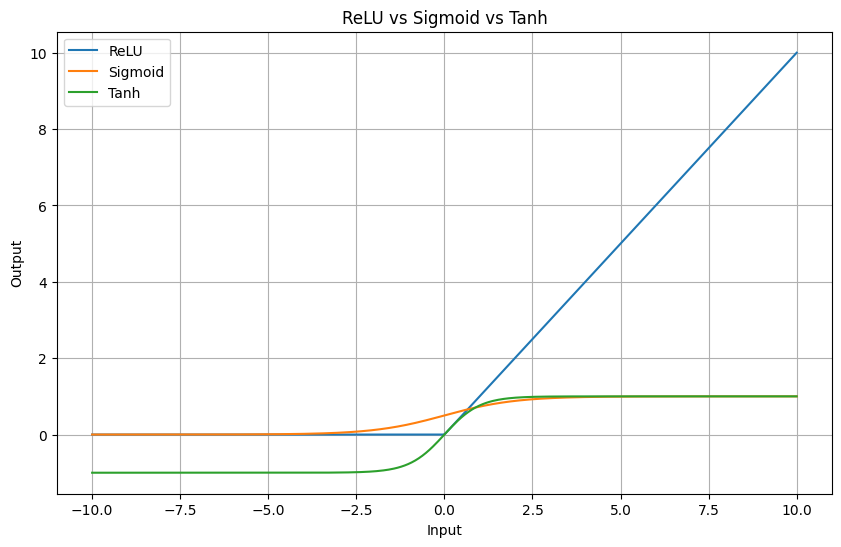

In [144]:
x = np.linspace(-10, 10, 400)

# Activation functions
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(x, relu, label="ReLU")
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")

plt.title("ReLU vs Sigmoid vs Tanh")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)

plt.show()

#### Output Activation and Loss Function

For the Phase 3 project, the task is a **binary classification** problem, where the target has two classes (0 and 1).

##### Output Activation: Sigmoid

We use the **Sigmoid** activation function in the output layer:

- Produces a value between `0` and `1`.
- Represents the probability that an observation belongs to class `1`.
- A threshold of `0.5` can be used to convert probabilities into class predictions.

##### Loss Function: Binary Cross-Entropy

We use **Binary Cross-Entropy (`binary_crossentropy`)** because:

- It is designed for binary classification problems.
- It measures the difference between the predicted probability and the actual binary label.
- It penalizes confident incorrect predictions more strongly.

##### Final Choice

```python
layers.Dense(1, activation='sigmoid')

In [145]:
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Model Architecture

The neural network consists of:

- **Input layer:** Accepts the scaled input features.
- **Dense layer (32 neurons):** Uses the `ReLU` activation function.
- **Dropout (0.3):** Helps reduce overfitting.
- **Dense layer (16 neurons):** Uses the `ReLU` activation function.
- **Dropout (0.2):** Further reduces overfitting.
- **Output layer (1 neuron):** Uses `Sigmoid` for binary classification.

##### Model Parameters

- **Total parameters:** 1,217
- **Trainable parameters:** 1,217
- **Non-trainable parameters:** 0

The model uses **Sigmoid** in the output layer because this is a binary classification task, and **Binary Cross-Entropy** as the loss function because it is appropriate for binary targets (`0` and `1`).

In [146]:
# Take one real sample from the training data
X_sample = X_train_scaled[0:1]

# Get weights and biases
W1, b1 = nn_model.layers[0].get_weights()
W2, b2 = nn_model.layers[2].get_weights()
W3, b3 = nn_model.layers[4].get_weights()

# Forward pass
z1 = X_sample @ W1 + b1
a1 = np.maximum(0, z1)  # ReLU

z2 = a1 @ W2 + b2
a2 = np.maximum(0, z2)  # ReLU

z3 = a2 @ W3 + b3
y_pred = 1 / (1 + np.exp(-z3))  # Sigmoid

print("Input:", X_sample)
print("Hidden layer 1:", a1)
print("Hidden layer 2:", a2)
print("Output probability:", y_pred)

Input: [[ 0.10513281  0.58078691  1.79205735  1.227727   -0.1700222  -0.71637006
  -0.43759497  1.70171938  0.09091641 -0.73812437 -0.29356577 -0.32836989
  -0.39708115 -0.2826917 ]]
Hidden layer 1: [[0.         0.         0.         0.18860853 1.37533462 1.35220984
  0.         0.         0.         0.         0.0335185  0.
  0.         0.12588777 0.10270308 1.07066309 0.02042776 0.
  0.         0.34939056 0.33768173 0.20507067 0.         0.15412388
  0.         0.35318878 0.30699657 0.         1.44495594 0.
  0.34605689 0.16597623]]
Hidden layer 2: [[0.         0.80503745 0.08050756 0.         0.2732253  0.1699398
  0.38696767 0.96602029 0.02976343 0.         0.07803742 0.
  0.         0.01076372 0.13324054 0.31954518]]
Output probability: [[0.40456594]]


#### Forward Pass Using a Real Sample

A real sample from `X_train_scaled` was passed through the trained neural network.

- The first hidden layer applies **ReLU**.
- The second hidden layer applies **ReLU**.
- The output layer applies **Sigmoid** to produce the probability of class `0`.

This demonstrates the complete forward pass from the input features to the final prediction.

#### Forward Pass Using a Real Sample

A real sample from the scaled training data was passed through the trained neural network.

- **Input:** 20 scaled features.
- **Hidden Layer 1:** 32 neurons with **ReLU** activation.
- **Hidden Layer 2:** 16 neurons with **ReLU** activation.
- **Output Layer:** **Sigmoid** activation produced a probability of **0.4013**.

##### Prediction

The output probability is approximately **40.13%** for class `1`.

Using a threshold of `0.5`, the model predicts:

**Class 0**

##### Model Choices

- **Hidden layers:** ReLU activation was used because it is simple, efficient, and helps the network learn nonlinear patterns.
- **Output layer:** Sigmoid activation was used because this is a binary classification problem and it produces a probability between 0 and 1.
- **Loss function:** Binary Cross-Entropy was selected because it is appropriate for binary classification.

###### Forward-Pass Result

A real sample from `X_train_scaled` was passed through the trained network.

- **Hidden Layer 1:** 32 neurons with ReLU
- **Hidden Layer 2:** 16 neurons with ReLU
- **Output probability:** `0.4013`

Since the probability is below the `0.5` threshold, the final prediction is:

**Predicted Class: 0**

This demonstrates how the input features are transformed through the hidden layers to produce the final classification probability.

### Four-Step Training Loop

1. **Forward Pass** → The model takes the input data and produces predictions.
2. **Compute Loss** → Compare predictions with the true values to measure the error.
3. **Backpropagation** → Calculate how the error affects each model weight.
4. **Update Weights** → The optimizer adjusts the weights to reduce the loss.

**Training Loop:**

`Input → Forward Pass → Loss → Backpropagation → Update Weights → Repeat`

The loop is repeated over multiple batches and epochs until the model learns useful patterns and minimizes the loss.

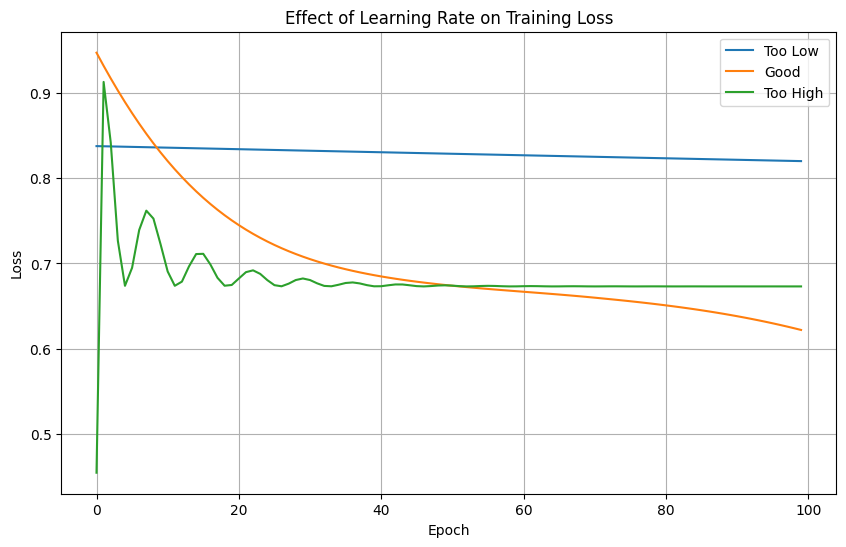

In [149]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Tiny dataset
X = np.array([[0], [1], [2], [3], [4]], dtype=float)
y = np.array([[0], [0], [1], [1], [1]], dtype=float)

learning_rates = {
    "Too Low": 0.0001,
    "Good": 0.01,
    "Too High": 1.0
}

loss_curves = {}

for name, lr in learning_rates.items():

    # Create a new tiny network
    lr_model = Sequential([
        Dense(4, activation="relu", input_shape=(1,)),
        Dense(1, activation="sigmoid")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    lr_model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy"
    )

    history = lr_model.fit(
        X,
        y,
        epochs=100,
        verbose=0
    )

    loss_curves[name] = history.history["loss"]

# Plot loss curves
plt.figure(figsize=(10, 6))

for name, losses in loss_curves.items():
    plt.plot(losses, label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### Learning Rate Experiment

Three learning rates were tested:

- **Too Low (0.0001):** The loss decreases very slowly and remains almost constant.
- **Good (0.01):** The loss decreases steadily and reaches the lowest value, indicating effective learning.
- **Too High (1.0):** The loss fluctuates and remains high, showing unstable training.

**Conclusion:** A learning rate of **0.01** provides the best balance between learning speed and training stability.

### Backpropagation and the Chain Rule

**Backpropagation** computes how much each weight and bias contributes to the model's prediction error. It calculates the **gradient of the loss with respect to each parameter**, which helps the optimizer update the weights and reduce the loss.

The **chain rule** is needed because a neural network has multiple connected layers. The final loss depends on earlier weights through several intermediate calculations. The chain rule allows us to calculate how a change in each parameter affects the final loss by combining the gradients through each layer.

In simple terms:

`Prediction → Loss → Backpropagation → Gradients → Update Weights`

Therefore, backpropagation uses the chain rule to efficiently calculate the gradients needed to train a neural network.